In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
import os

print(os.getcwd())

/Users/adithyant/Desktop/internship/zelbytes-yield-/notebooks


In [4]:
import pandas as pd

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

print(X_train.shape)
print(X_test.shape)

(96, 3)
(24, 3)


In [5]:
print(y_train.head())
print(type(y_train))

0    13.825416
1    13.813510
2    14.305479
3    13.021004
4    13.681953
Name: yield_kg, dtype: float64
<class 'pandas.Series'>


In [6]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print("Random Forest trained successfully")

Random Forest trained successfully


In [7]:
y_pred = rf.predict(X_test)

print(y_pred[:5])

[13.54199317 13.51065292 12.72800754 12.4503696  13.29072645]


In [8]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae, 3))
print("MSE :", round(mse, 3))
print("RMSE:", round(rmse, 3))
print("R2  :", round(r2, 3))

MAE : 0.962
MSE : 1.36
RMSE: 1.166
R2  : -0.041


In [9]:
train_pred = rf.predict(X_train)

train_mae = mean_absolute_error(
    y_train,
    train_pred
)

print("Train MAE:", round(train_mae, 3))
print("Test MAE :", round(mae, 3))

Train MAE: 0.275
Test MAE : 0.962


In [10]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
2,co2,0.434129
1,humidity,0.315511
0,temperature,0.250360


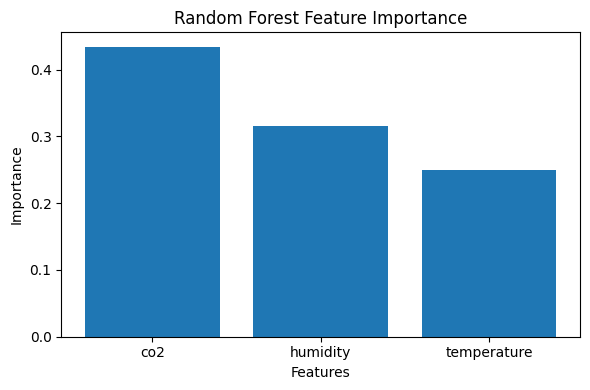

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.tight_layout()
plt.show()

In [12]:
from sklearn.model_selection import (
    TimeSeriesSplit,
    cross_val_score
)
from sklearn.linear_model import LinearRegression

In [13]:
tscv = TimeSeriesSplit(n_splits=3)

print(tscv)

TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None)


In [14]:
lr = LinearRegression()

lr_scores = -cross_val_score(
    lr,
    X_train,
    y_train,
    cv=tscv,
    scoring="neg_mean_absolute_error"
)

print("Linear Regression CV Scores")
print(lr_scores)

print("Mean CV MAE:", lr_scores.mean())

Linear Regression CV Scores
[0.95296197 0.81692118 0.85765186]
Mean CV MAE: 0.8758450033132474


In [15]:
rf_scores = -cross_val_score(
    rf,
    X_train,
    y_train,
    cv=tscv,
    scoring="neg_mean_absolute_error"
)

print("Random Forest CV Scores")
print(rf_scores)

print("Mean CV MAE:", rf_scores.mean())

Random Forest CV Scores
[0.90369332 0.85810327 0.80637577]
Mean CV MAE: 0.8560574529491417


In [16]:
lr = LinearRegression()

lr_scores = -cross_val_score(
    lr,
    X_train,
    y_train,
    cv=tscv,
    scoring="neg_mean_absolute_error"
)

print("Linear Regression CV Scores")
print(lr_scores)

print("Mean CV MAE:", lr_scores.mean())

Linear Regression CV Scores
[0.95296197 0.81692118 0.85765186]
Mean CV MAE: 0.8758450033132474
